# Ablation study: F1 vs. cantidad de datos de entrenamiento/validación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader
import torch
import json
import os
import sys
from tqdm import tqdm

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_gait import load_dataset_gait
from src.train_LSTMGait import (
    LSTMGaitDataset,
    normalize_per_window,
    training_loop,
)
from models.LSTMGait import CNNBiLSTMGait

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

In [ ]:
base_path = '../datasets/GAIT_signals/dataset/data'
out_dir = '../checkpoints/ablation_datasize'
os.makedirs(out_dir, exist_ok=True)

BEST_CONFIG = dict(
    process='free_raw',
    sensors=['LB'],        
    window_size=200,
    stride=50,
    norm='window',
)

MODEL_KWARGS = dict(
    cnn_channels=64,
    kernel_size=5,
    hidden_size=128,
    num_layers=2,
    dropout_rate=0.25,
)

FRACTIONS = [0.10, 0.25, 0.50, 0.75, 1.00]
N_REPEATS = 5          
TEST_FRACTION = 0.20
VAL_FRACTION = 0.20  


EPOCHS = 200
PATIENCE = 20
LR = 0.0003
BATCH_SIZE = 128

## 1. Cargar el dataset

In [3]:
X_all, y_all, groups = load_dataset_gait(
    base_path,
    process=BEST_CONFIG['process'],
    sensors=BEST_CONFIG['sensors'],
    window_size=BEST_CONFIG['window_size'],
    stride=BEST_CONFIG['stride'],
)

print(f"X_all: {X_all.shape}  |  y_all: {y_all.shape}  |  sujetos únicos: {len(np.unique(groups))}")

X_all: (76460, 200, 9)  |  y_all: (76460, 200)  |  sujetos únicos: 260


In [ ]:
def cohort_of(subject):
    return subject.split('_')[0]

unique_subjects = np.unique(groups)
cohort_per_subject = {s: cohort_of(s) for s in unique_subjects}

cohort_counts = pd.Series(cohort_per_subject).value_counts().sort_values()
print("Sujetos por patología (dataset completo):")
print(cohort_counts)

Sujetos por patología (dataset completo):
ACL     11
HOA     15
KOA     18
CIPN    19
PD      24
CVA     49
RIL     51
HS      73
Name: count, dtype: int64


## 2. Split de test global fijo

In [5]:
gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_FRACTION, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(unique_subjects, groups=unique_subjects))

trainval_pool_subjects = unique_subjects[trainval_idx]
test_subjects = set(unique_subjects[test_idx])

print(f"Pool train+val: {len(trainval_pool_subjects)} sujetos  |  Test (fijo): {len(test_subjects)} sujetos")

# Sanity check: todas las patologías deberían tener representación en ambos lados
test_cohort_counts = pd.Series([cohort_per_subject[s] for s in test_subjects]).value_counts()
print("\nPatologías representadas en test:")
print(test_cohort_counts.sort_values())

Pool train+val: 208 sujetos  |  Test (fijo): 52 sujetos

Patologías representadas en test:
HOA      2
ACL      3
CIPN     5
KOA      5
CVA      7
PD       7
RIL     10
HS      13
Name: count, dtype: int64


In [ ]:
test_mask = np.isin(groups, list(test_subjects))
X_test, y_test = X_all[test_mask], y_all[test_mask]


X_test_norm = normalize_per_window(X_test).astype(np.float32)
y_test_cast = y_test.astype(np.int64)
test_dl = DataLoader(LSTMGaitDataset(X_test_norm, y_test_cast), batch_size=BATCH_SIZE, shuffle=False)

print(f"Test: {X_test.shape[0]} ventanas de {len(test_subjects)} sujetos (fijo para toda la ablación)")

Test: 17108 ventanas de 52 sujetos (fijo para toda la ablación)


## 3. Muestreo estratificado de sujetos 

In [7]:
trainval_by_cohort = {}
for s in trainval_pool_subjects:
    trainval_by_cohort.setdefault(cohort_per_subject[s], []).append(s)

print("Sujetos por patología en el pool de train+val:")
for c, subs in sorted(trainval_by_cohort.items(), key=lambda kv: len(kv[1])):
    print(f"  {c:12s}: {len(subs)}")

Sujetos por patología en el pool de train+val:
  ACL         : 8
  HOA         : 13
  KOA         : 13
  CIPN        : 14
  PD          : 17
  RIL         : 41
  CVA         : 42
  HS          : 60


In [8]:
def sample_stratified_subjects(trainval_by_cohort, fraction, rng):
    """Muestrea sujetos manteniendo representación mínima de cada patología."""
    sampled = []
    for cohort, subjects in trainval_by_cohort.items():
        n_take = max(1, round(fraction * len(subjects)))
        n_take = min(n_take, len(subjects))
        chosen = rng.choice(subjects, size=n_take, replace=False)
        sampled.extend(chosen.tolist())
    return sampled


def split_train_val(sampled_subjects, val_fraction, seed):
    """Split 80/20 (por defecto) dentro de los sujetos muestreados."""
    sampled_subjects = np.array(sampled_subjects)
    if len(sampled_subjects) < 5:
        raise ValueError("Muy pocos sujetos para hacer un split train/val fiable.")
    gss = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    tr_idx, va_idx = next(gss.split(sampled_subjects, groups=sampled_subjects))
    return set(sampled_subjects[tr_idx]), set(sampled_subjects[va_idx])

## 4. Bucle de ablación

In [9]:
def run_single_experiment(fraction, repeat_idx, seed):
    rng = np.random.default_rng(seed)

    sampled_subjects = sample_stratified_subjects(trainval_by_cohort, fraction, rng)
    train_subjects, val_subjects = split_train_val(sampled_subjects, VAL_FRACTION, seed)

    train_mask = np.isin(groups, list(train_subjects))
    val_mask   = np.isin(groups, list(val_subjects))

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_val,   y_val   = X_all[val_mask],   y_all[val_mask]

    X_train = normalize_per_window(X_train).astype(np.float32)
    X_val   = normalize_per_window(X_val).astype(np.float32)
    y_train = y_train.astype(np.int64)
    y_val   = y_val.astype(np.int64)

    g = torch.Generator()
    g.manual_seed(seed)
    train_dl = DataLoader(LSTMGaitDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, generator=g)
    val_dl   = DataLoader(LSTMGaitDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)

    num_channels = X_all.shape[-1]
    num_classes  = len(np.unique(y_all))

    model = CNNBiLSTMGait(num_channels, num_classes, **MODEL_KWARGS)
    model, best_val_f1 = training_loop(model, train_dl, val_dl, num_classes,
                                        epochs=EPOCHS, lr=LR, patience=PATIENCE)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device).eval()
    test_preds, test_true = [], []
    with torch.no_grad():
        for x, y in test_dl:
            x = x.to(device)
            preds = model(x).argmax(dim=2).cpu().numpy().flatten()
            test_preds.extend(preds)
            test_true.extend(y.numpy().flatten())
    test_f1 = f1_score(test_true, test_preds, average='macro')

    return {
        "fraction": fraction,
        "repeat": repeat_idx,
        "seed": seed,
        "n_sampled_subjects": len(sampled_subjects),
        "n_train_subjects": len(train_subjects),
        "n_val_subjects": len(val_subjects),
        "n_train_windows": int(X_train.shape[0]),
        "n_val_windows": int(X_val.shape[0]),
        "val_f1": float(best_val_f1),
        "test_f1": float(test_f1),
    }

In [10]:
results_path = os.path.join(out_dir, "results_ablation.json")

if os.path.exists(results_path):
    with open(results_path) as f:
        results = json.load(f)
else:
    results = []

done = {(r["fraction"], r["repeat"]) for r in results}

runs = [(frac, rep) for frac in FRACTIONS for rep in range(N_REPEATS)]
pbar = tqdm(runs, desc="Ablation")

for fraction, repeat_idx in pbar:
    if (fraction, repeat_idx) in done:
        continue
    seed = RANDOM_STATE * 1000 + int(fraction * 100) * 10 + repeat_idx
    pbar.set_postfix({"fraction": fraction, "repeat": repeat_idx})

    result = run_single_experiment(fraction, repeat_idx, seed)
    results.append(result)

    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)

results_df = pd.DataFrame(results)
results_df

                                                                        
Ablation:   0%|          | 0/25 [00:19<?, ?it/s, fraction=0.1, repeat=3]             

Early stopping in epoch 31. Best F1: 0.9096


                                                                                
Ablation:  16%|█▌        | 4/25 [00:45<01:53,  5.42s/it, fraction=0.1, repeat=4]     

Early stopping in epoch 27. Best F1: 0.6810


                                                                                 
Ablation:  20%|██        | 5/25 [02:00<03:36, 10.84s/it, fraction=0.25, repeat=0]    

...

Early stopping in epoch 44. Best F1: 0.8709


                                                                                
Ablation:  96%|█████████▌| 24/25 [1:03:24<04:53, 293.62s/it, fraction=1, repeat=4]   

Early stopping in epoch 32. Best F1: 0.8751


Ablation: 100%|██████████| 25/25 [1:03:26<00:00, 152.26s/it, fraction=1, repeat=4]


,fraction,repeat,seed,n_sampled_subjects,n_train_subjects,n_val_subjects,n_train_windows,n_val_windows,val_f1,test_f1
0,0.10,0,42100,20,16,4,4159,1438,0.690634,0.811749
1,0.10,1,42101,20,16,4,4507,1001,0.898670,0.814006
2,0.10,2,42102,20,16,4,3700,1294,0.648474,0.812212
3,0.10,3,42103,20,16,4,3678,775,0.909568,0.801807
4,0.10,4,42104,20,16,4,5024,1601,0.681029,0.820588
5,0.25,0,42250,51,40,11,11849,2829,0.889791,0.836311
6,0.25,1,42251,51,40,11,11052,2991,0.863735,0.840119
7,0.25,2,42252,51,40,11,10407,5959,0.854542,0.834177
8,0.25,3,42253,51,40,11,10661,2587,0.847001,0.823586
9,0.25,4,42254,51,40,11,12271,2284,0.881691,0.850422


In [11]:
summary = (
    results_df
    .groupby("fraction")
    .agg(
        n_train_subjects_mean=("n_train_subjects", "mean"),
        val_f1_mean=("val_f1", "mean"),
        val_f1_std=("val_f1", "std"),
        test_f1_mean=("test_f1", "mean"),
        test_f1_std=("test_f1", "std"),
    )
    .reset_index()
)
summary

,fraction,n_train_subjects_mean,val_f1_mean,val_f1_std,test_f1_mean,test_f1_std
0,0.10,16.0,0.765675,0.127402,0.812072,0.006741
1,0.25,40.0,0.867352,0.018031,0.836923,0.009724
2,0.50,81.0,0.866500,0.037939,0.846873,0.010132
3,0.75,125.0,0.870156,0.011899,0.857175,0.004235
4,1.00,166.0,0.868026,0.007817,0.861866,0.004683


## 6. Curva de aprendizaje

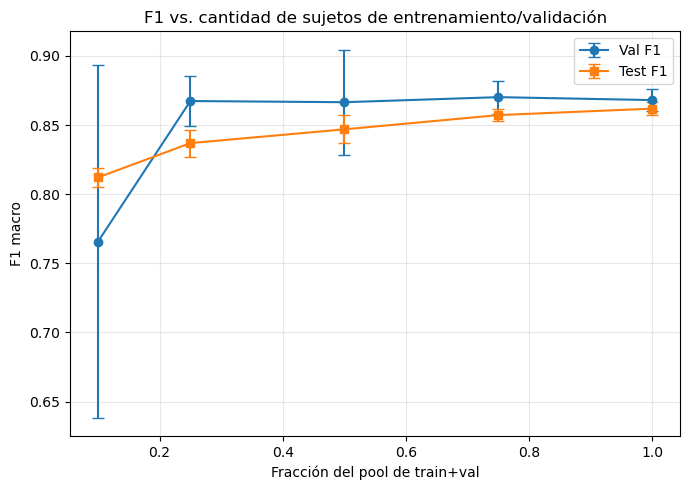

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(summary["fraction"], summary["val_f1_mean"], yerr=summary["val_f1_std"],
            marker="o", capsize=4, label="Val F1")
ax.errorbar(summary["fraction"], summary["test_f1_mean"], yerr=summary["test_f1_std"],
            marker="s", capsize=4, label="Test F1")

ax.set_xlabel("Fracción del pool de train+val")
ax.set_ylabel("F1 macro")
ax.set_title("F1 vs. cantidad de sujetos de entrenamiento/validación")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "learning_curve.png"), dpi=150)
plt.show()